In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"D:\python_projects\project 3\soil_cover_type.csv")
data

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29


# Data Understanding

**1 .checking shape of the dataframes :**

In [ ]:
print ('data shape : ',data.shape)

**2 .checking info of the dataframes :**

In [ ]:
data.info()

 Separate numerical and categorical columns

In [ ]:
data_nc = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
data_cc = data.select_dtypes(include=['object']).columns.tolist()
print(f"  Numerical columns ({len(data_nc)}): {data_nc}")
print(f"\n Categorical columns ({len(data_cc)}): {data_cc}")
print()

 **3 .printing total missing values of the dataframes :**


In [ ]:
data.isnull().sum()

 **4.checking datatypes of the dataframes :**

In [ ]:
data.dtypes

 **5.checking duplicated values of the dataframes :**

In [ ]:
data.duplicated().sum()

 **6.understanding the data using statistics :**

In [ ]:
data.describe()

In [ ]:
print("Unique values:")
for i, col in enumerate(data.columns):
    print(i, col,'-', data[col].nunique())


In [ ]:
counts = data['Cover_Type'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.xticks(rotation = 30)
plt.title("Cover Type Distribution")
plt.show()
print('\n Total Values:')
print(data['Cover_Type'].value_counts())


**Check skewness of numerical columns**

In [ ]:
print(data[data_nc].skew().sort_values(ascending=False))

In [ ]:
plt.figure(figsize=(11,5))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - All Data')
plt.show()

 **Final summary of data understanding**

In [ ]:
print(f"Total Rows: {data.shape[0]}")
print(f"Total Columns: {data.shape[1]}")
print(f"Numerical Columns: {len(data_nc)}")
print(f"Categorical Columns: {len(data_cc)}")
print(f"Total Missing Values: {data.isnull().sum().sum()}")
print(f"Total Duplicate Rows: {data.duplicated().sum()}\n")

# Data Cleaning

 **1: Clean and rename column names :**

In [3]:
df_data = data.copy()
df_data  = df_data.rename(columns={
    'Horizontal_Distance_To_Hydrology':'Horizontal_Dist_To_water',
    'Vertical_Distance_To_Hydrology':'Vertical_Dist_To_water',
    'Horizontal_Distance_To_Fire_Points':'Horizontal_Dist_To_Fire',
})
df_data.columns = df_data.columns.str.lower().str.replace(' ', '_')
df_data['cover_type'] = df_data['cover_type'].str.strip().str.title()

print("df_data - Column names cleaned:")
print(df_data.columns.tolist())
print()

df_data - Column names cleaned:
['elevation', 'aspect', 'slope', 'horizontal_dist_to_water', 'vertical_dist_to_water', 'horizontal_distance_to_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'horizontal_dist_to_fire', 'cover_type', 'wilderness_area', 'soil_type']



 **2: handling skewness :**

In [4]:
df_data_nc = df_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
df_data_cc = df_data.select_dtypes(include=['object']).columns.tolist()

df_data[df_data_nc].skew().sort_values()

hillshade_9am                     -1.286839
hillshade_noon                    -0.945446
soil_type                         -0.692105
elevation                         -0.664497
hillshade_3pm                     -0.165213
horizontal_distance_to_roadways   -0.058240
horizontal_dist_to_fire            0.365249
aspect                             0.689432
slope                              0.943937
horizontal_dist_to_water           0.984953
vertical_dist_to_water             1.792939
wilderness_area                    3.423545
dtype: float64

In [5]:
from sklearn.preprocessing import PowerTransformer
sqrt_cols = ['aspect','slope','horizontal_dist_to_water']
for col in sqrt_cols:
    df_data[col] = np.sqrt(df_data[col])

yeo_cols = ['vertical_dist_to_water','hillshade_9am','hillshade_noon','elevation']
pt = PowerTransformer(method='yeo-johnson')
df_data[yeo_cols] = pt.fit_transform(df_data[yeo_cols])

#checking skewness after transformation:
print("Skewness after transformation:\n")
print(df_data[sqrt_cols + yeo_cols].skew())

Skewness after transformation:

aspect                      0.065918
slope                       0.054627
horizontal_dist_to_water   -0.120930
vertical_dist_to_water      0.308290
hillshade_9am              -0.109124
hillshade_noon             -0.026800
elevation                   0.067272
dtype: float64


 **3: handling outliers :**

checking for outliers:

In [6]:
numeric_cols = ['elevation','aspect','slope','horizontal_dist_to_water','vertical_dist_to_water',
    'horizontal_distance_to_roadways','hillshade_9am','hillshade_noon','hillshade_3pm',
    'horizontal_dist_to_fire']

for col in numeric_cols:
    Q1 = df_data[col].quantile(0.25)
    Q3 = df_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_data[(df_data[col] < lower) | (df_data[col] > upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(df_data)*100, 2)}%)")
print()

elevation — Outliers: 3428 (2.35%)
aspect — Outliers: 0 (0.0%)
slope — Outliers: 1203 (0.82%)
horizontal_dist_to_water — Outliers: 89 (0.06%)
vertical_dist_to_water — Outliers: 7179 (4.92%)
horizontal_distance_to_roadways — Outliers: 0 (0.0%)
hillshade_9am — Outliers: 0 (0.0%)
hillshade_noon — Outliers: 424 (0.29%)
hillshade_3pm — Outliers: 3087 (2.12%)
horizontal_dist_to_fire — Outliers: 0 (0.0%)



# EDA

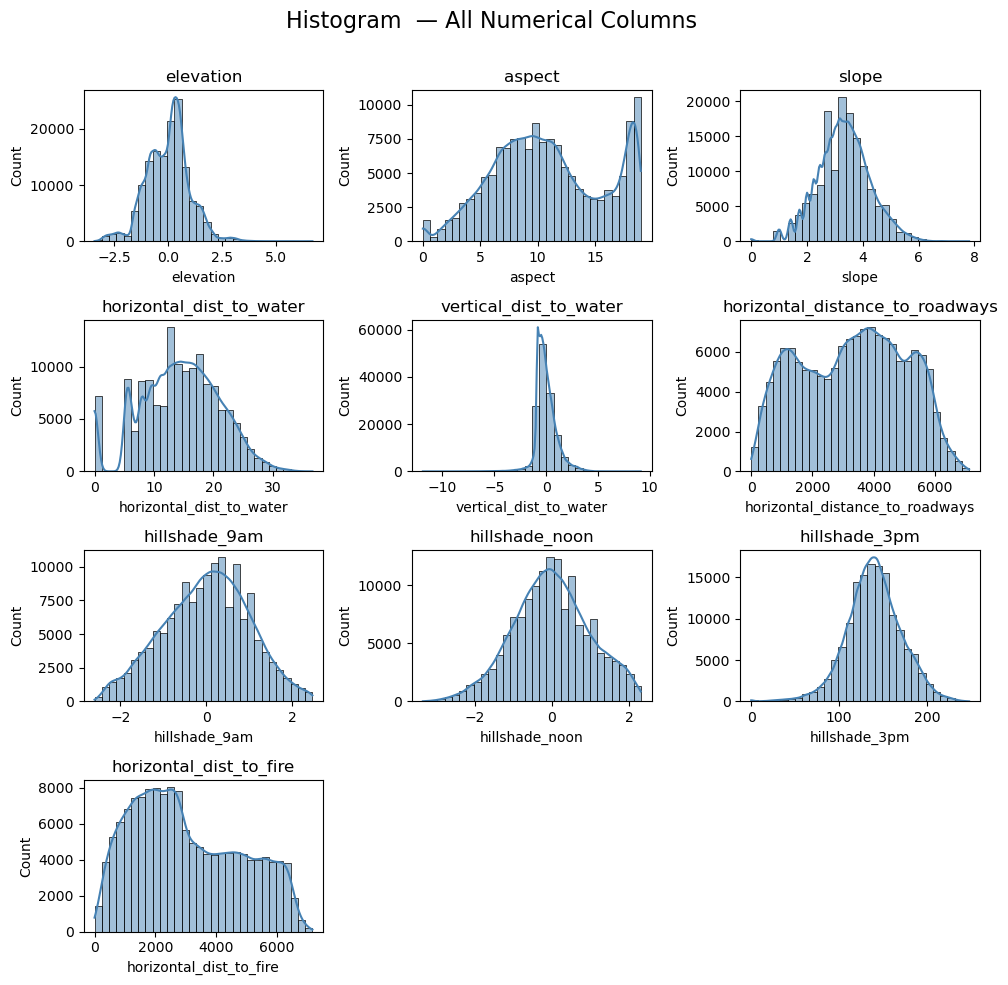

In [7]:
# Histogram — distribution of all numerical columns
plt.figure(figsize=(10,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)  
    sns.histplot(df_data[col], bins=30, kde=True, color='steelblue', edgecolor='black')
    plt.title(col)

plt.suptitle('Histogram  — All Numerical Columns \n', fontsize=16)
plt.tight_layout()
plt.show()

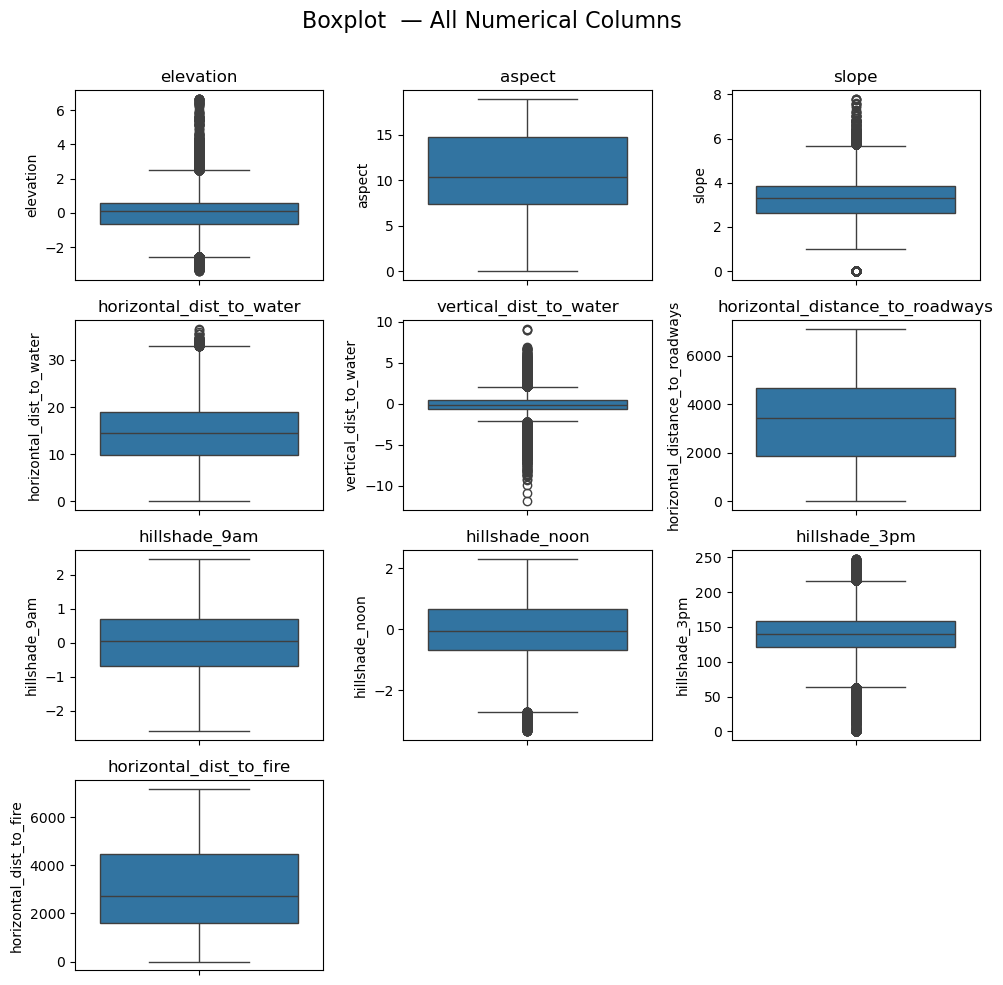

In [8]:
# boxplot — outlier of all numerical columns
plt.figure(figsize=(10,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)  
    sns.boxplot(df_data[col])
    plt.title(col)

plt.suptitle('Boxplot  — All Numerical Columns \n', fontsize=16)
plt.tight_layout()
plt.show()

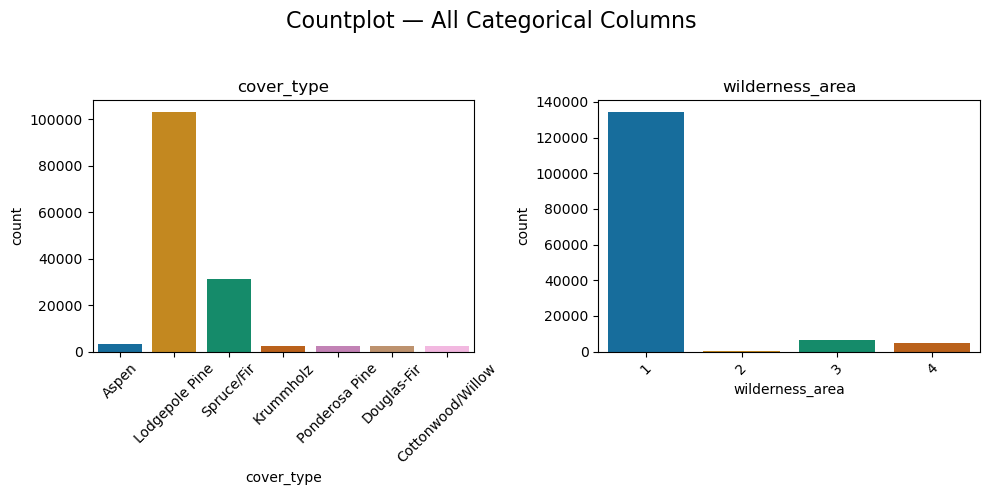

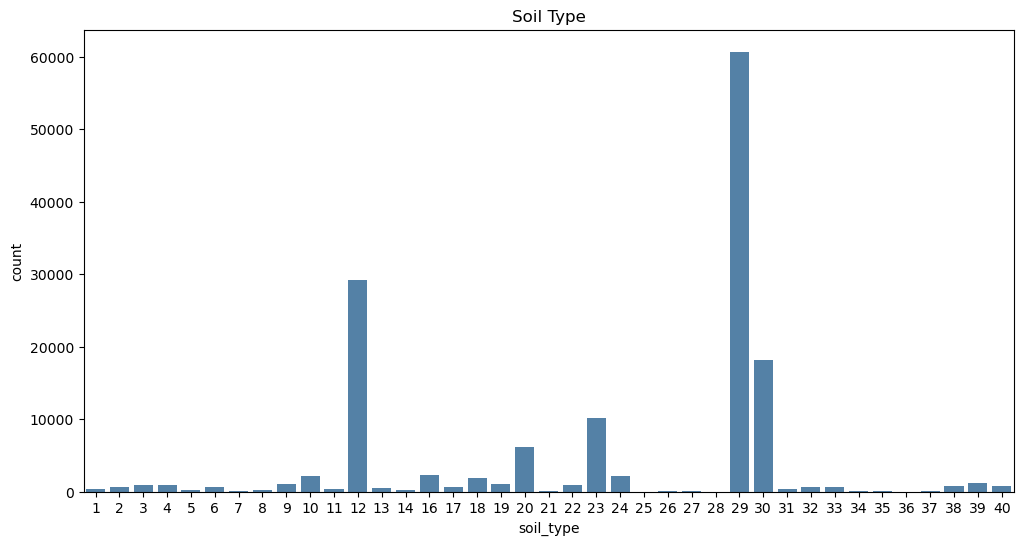

In [9]:
# Countplot — frequency of each categorical column
df_data_cc = ['cover_type' ,'wilderness_area']
plt.figure(figsize=(10, 5))
for i, col in enumerate(df_data_cc):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=df_data[col], hue=df_data[col], palette='colorblind', legend=False)
    plt.title(col)
    plt.xticks(rotation=45)
plt.suptitle('Countplot — All Categorical Columns \n', fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df_data, x='soil_type', color='steelblue')
plt.title('Soil Type')
plt.show()

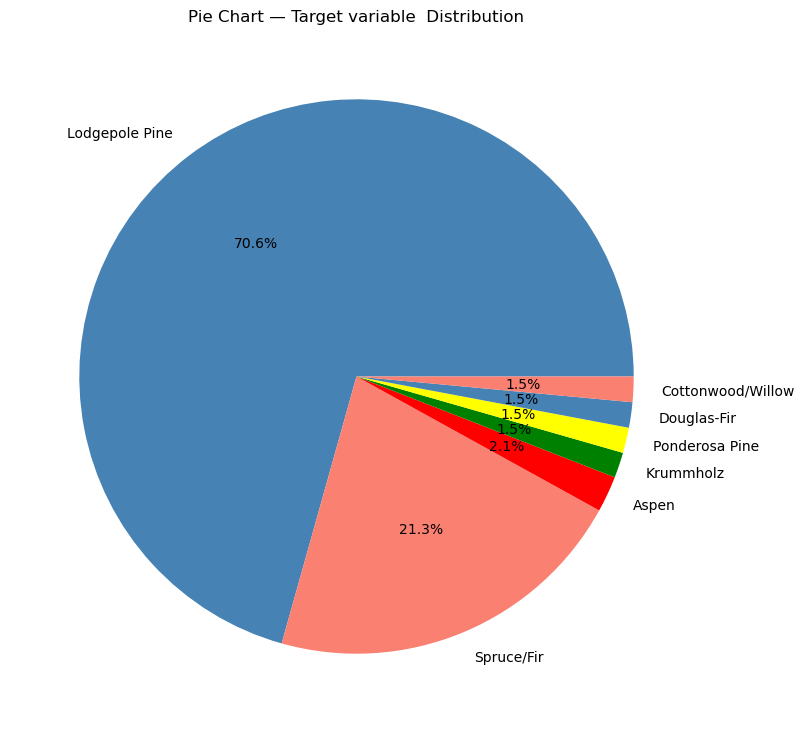

In [10]:
# Pie Chart — proportion of target variable
plt.figure(figsize=(9, 9))
df_data['cover_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'salmon','red','green','yellow'])
plt.title('Pie Chart — Target variable  Distribution')
plt.ylabel('')
plt.show()

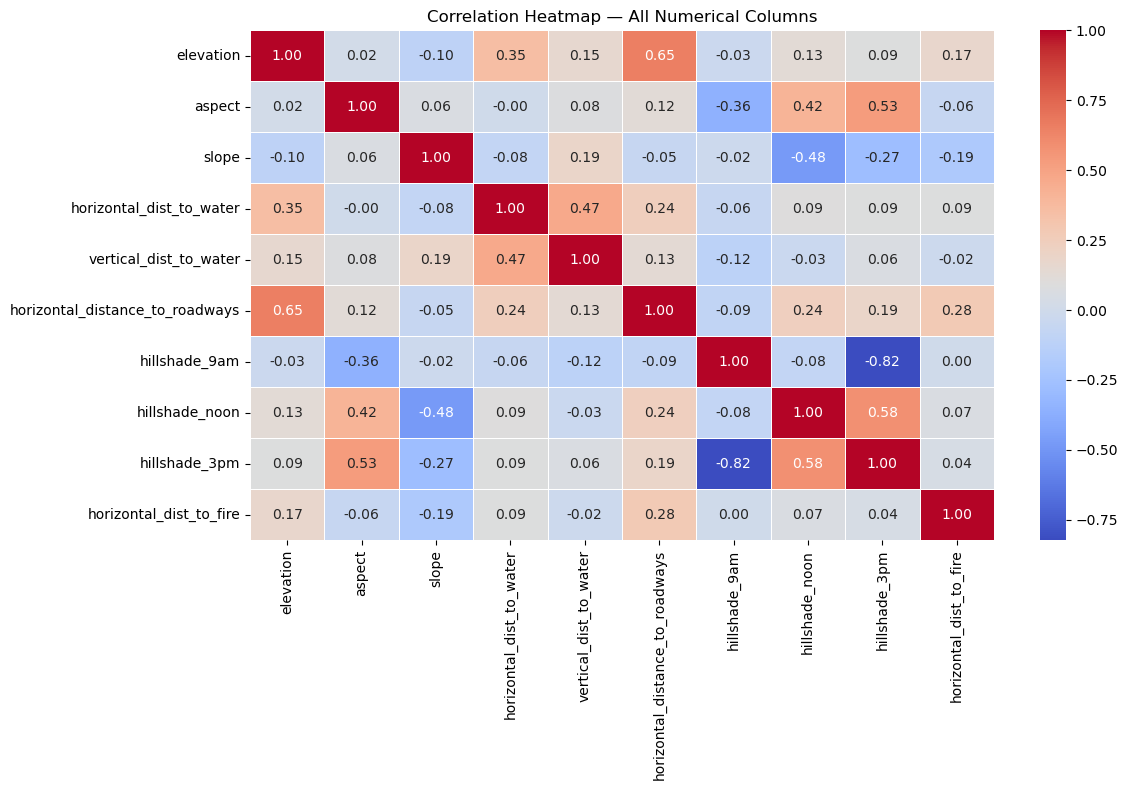

In [11]:
# Correlation Heatmap — relationships between all numerical columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_data[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — All Numerical Columns')
plt.tight_layout()
plt.show()

# Feature engineering

In [12]:
# Check highly correlated features above 0.8
corr_matrix = df_data[numeric_cols].corr().abs()

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if corr_matrix.loc[row, col] > 0.8 and row != col:
            print(f"{col} — {row} : {corr_matrix.loc[row, col].round(3)}")

hillshade_9am — hillshade_3pm : 0.822
hillshade_3pm — hillshade_9am : 0.822


In [13]:
df_data['total_distance'] = (
    df_data['horizontal_dist_to_fire'] +
    df_data['horizontal_distance_to_roadways'] +
    df_data['horizontal_dist_to_water']
)

# Average shade
df_data['avg_hillshade'] = (
    df_data['hillshade_9am'] +
    df_data['hillshade_noon'] +
    df_data['hillshade_3pm']
) / 3

# Water distance
df_data['water_distance'] = np.sqrt(
    df_data['horizontal_dist_to_water']**2 +
    df_data['vertical_dist_to_water']**2
)

# Shade variation
df_data['shade_range'] = (
    df_data[['hillshade_9am',
             'hillshade_noon',
             'hillshade_3pm']].max(axis=1)
    -
    df_data[['hillshade_9am',
             'hillshade_noon',
             'hillshade_3pm']].min(axis=1)
)

# Elevation × slope
df_data['elevation_slope'] = (
    df_data['elevation'] *
    df_data['slope']
)

#drop columns with high collinearity:
df_data = df_data.drop(columns=['hillshade_3pm'])

In [14]:
# checking for class imbalance
print (df_data['cover_type'].value_counts(normalize=True) * 100 , '\n')

print(df_data['soil_type'].value_counts(normalize=True).sort_index() * 100 ,'\n')

df_data['wilderness_area'].value_counts(normalize=True) * 100

cover_type
Lodgepole Pine       70.649805
Spruce/Fir           21.324285
Aspen                 2.103640
Krummholz             1.480568
Ponderosa Pine        1.480568
Douglas-Fir           1.480568
Cottonwood/Willow     1.480568
Name: proportion, dtype: float64 

soil_type
1      0.244019
2      0.427034
3      0.659401
4      0.577833
5      0.113099
6      0.445541
7      0.071972
8      0.122695
9      0.762218
10     1.468229
11     0.278292
12    19.976695
13     0.326273
14     0.115841
16     1.521009
17     0.419494
18     1.253684
19     0.716979
20     4.179862
21     0.010967
22     0.638152
23     6.957297
24     1.486737
25     0.000685
26     0.037014
27     0.010282
28     0.006169
29    41.603948
30    12.446364
31     0.227569
32     0.472959
33     0.422236
34     0.015080
35     0.069916
36     0.006854
37     0.023305
38     0.550415
39     0.829392
40     0.504490
Name: proportion, dtype: float64 



wilderness_area
1    92.101583
3     4.351909
4     3.204469
2     0.342039
Name: proportion, dtype: float64

**Train_test_split**

In [15]:
from sklearn.model_selection import train_test_split

x = df_data.drop('cover_type', axis=1)
y = df_data['cover_type']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify= y)

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"\n x_train: {x_train.shape}, x_test: {x_test.shape}")


x shape: (145890, 16)
y shape: (145890,)

Class distribution:
cover_type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-Fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64

 x_train: (116712, 16), x_test: (29178, 16)


In [16]:
from sklearn.model_selection import StratifiedKFold, KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("KFold and StratifiedKFold defined!")

KFold and StratifiedKFold defined!


**encoding**

In [17]:
categorical_cols = ['soil_type', 'wilderness_area']

# Encode training data
x_train_ohe = pd.get_dummies(x_train, columns=categorical_cols, drop_first=True )

# Encode test data
x_test_ohe = pd.get_dummies( x_test, columns=categorical_cols, drop_first=True )

# Align columns
x_train_ohe, x_test_ohe = x_train_ohe.align(x_test_ohe, join='left', axis=1, fill_value=0 )

# Verify
print(f"\n x_train_ohe shape: {x_train_ohe.shape}, x_test_ohe shape: {x_test_ohe.shape}")
print(f"\nNew Columns Added:\n\n x_train_ohe\n :{x_train_ohe.columns.tolist()}, \n\n x_test_ohe :\n {x_test_ohe.columns.tolist()} ")
print("\nOneHot Encoding Done! ")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"\ny_train_encoded shape: {y_train_encoded.shape}")
print(f"y_test_encoded shape: {y_test_encoded.shape}")

print("\nEncoded Classes:")
print(le.classes_)

print("\nTarget Encoding Done!")




 x_train_ohe shape: (116712, 55), x_test_ohe shape: (29178, 55)

New Columns Added:

 x_train_ohe
 :['elevation', 'aspect', 'slope', 'horizontal_dist_to_water', 'vertical_dist_to_water', 'horizontal_distance_to_roadways', 'hillshade_9am', 'hillshade_noon', 'horizontal_dist_to_fire', 'total_distance', 'avg_hillshade', 'water_distance', 'shade_range', 'elevation_slope', 'soil_type_2', 'soil_type_3', 'soil_type_4', 'soil_type_5', 'soil_type_6', 'soil_type_7', 'soil_type_8', 'soil_type_9', 'soil_type_10', 'soil_type_11', 'soil_type_12', 'soil_type_13', 'soil_type_14', 'soil_type_16', 'soil_type_17', 'soil_type_18', 'soil_type_19', 'soil_type_20', 'soil_type_21', 'soil_type_22', 'soil_type_23', 'soil_type_24', 'soil_type_25', 'soil_type_26', 'soil_type_27', 'soil_type_28', 'soil_type_29', 'soil_type_30', 'soil_type_31', 'soil_type_32', 'soil_type_33', 'soil_type_34', 'soil_type_35', 'soil_type_36', 'soil_type_37', 'soil_type_38', 'soil_type_39', 'soil_type_40', 'wilderness_area_2', 'wilder

In [18]:
# Convert bool columns to int
bool_cols = x_train_ohe.select_dtypes(include='bool').columns
x_train_ohe[bool_cols] = x_train_ohe[bool_cols].astype(int)

# Convert category dtype to int
cat_dtype_cols = x_train_ohe.select_dtypes(include='category').columns
x_train_ohe[cat_dtype_cols] = x_train_ohe[cat_dtype_cols].astype(int)

# Verify
print(x_train_ohe.dtypes)
print(f"\nAny bool columns remaining: {x_train_ohe.select_dtypes(include='bool').columns.tolist()}")
print(f"Any category dtype remaining: {x_train_ohe.select_dtypes(include='category').columns.tolist()}")
print("\nAll fixed! ")

elevation                          float64
aspect                             float64
slope                              float64
horizontal_dist_to_water           float64
vertical_dist_to_water             float64
horizontal_distance_to_roadways      int64
hillshade_9am                      float64
hillshade_noon                     float64
horizontal_dist_to_fire              int64
total_distance                     float64
avg_hillshade                      float64
water_distance                     float64
shade_range                        float64
elevation_slope                    float64
soil_type_2                          int64
soil_type_3                          int64
soil_type_4                          int64
soil_type_5                          int64
soil_type_6                          int64
soil_type_7                          int64
soil_type_8                          int64
soil_type_9                          int64
soil_type_10                         int64
soil_type_1

In [19]:
# Convert bool columns to int
bool_cols = x_test_ohe.select_dtypes(include='bool').columns
x_test_ohe[bool_cols] = x_test_ohe[bool_cols].astype(int)

# Convert category dtype to int
cat_dtype_cols = x_test_ohe.select_dtypes(include='category').columns
x_test_ohe[cat_dtype_cols] = x_test_ohe[cat_dtype_cols].astype(int)

# Verify
print(x_train_ohe.dtypes)
print(f"\nAny bool columns remaining: {x_test_ohe.select_dtypes(include='bool').columns.tolist()}")
print(f"Any category dtype remaining: {x_test_ohe.select_dtypes(include='category').columns.tolist()}")
print("\nAll fixed! ")

elevation                          float64
aspect                             float64
slope                              float64
horizontal_dist_to_water           float64
vertical_dist_to_water             float64
horizontal_distance_to_roadways      int64
hillshade_9am                      float64
hillshade_noon                     float64
horizontal_dist_to_fire              int64
total_distance                     float64
avg_hillshade                      float64
water_distance                     float64
shade_range                        float64
elevation_slope                    float64
soil_type_2                          int64
soil_type_3                          int64
soil_type_4                          int64
soil_type_5                          int64
soil_type_6                          int64
soil_type_7                          int64
soil_type_8                          int64
soil_type_9                          int64
soil_type_10                         int64
soil_type_1

**scaling**

In [20]:
scaling_cols = ['elevation', 'aspect', 'slope', 'horizontal_dist_to_water',
       'vertical_dist_to_water', 'horizontal_distance_to_roadways',
       'hillshade_9am', 'hillshade_noon', 'horizontal_dist_to_fire','total_distance', 'avg_hillshade',
       'water_distance', 'shade_range', 'elevation_slope']



from sklearn.preprocessing import StandardScaler

# Copy datasets
x_train_scaled = x_train_ohe.copy()
x_test_scaled = x_test_ohe.copy()

scaler = StandardScaler()
x_train_scaled[scaling_cols] = scaler.fit_transform(x_train_ohe[scaling_cols])
x_test_scaled[scaling_cols] = scaler.transform(x_test_ohe[scaling_cols])

print("Scaling Done! ")


Scaling Done! 


In [21]:
import pickle

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save column names
with open('columns.pkl', 'wb') as f:
    pickle.dump(x_train_scaled.columns.tolist(), f)

print("Files saved successfully ")


Files saved successfully 


**Handling class imbalance**

In [22]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample( x_train_scaled,  y_train_encoded )
print('smote done')

smote done


In [23]:
#verify befire and after smote
print('Before smote: \n',pd.Series(y_train_encoded).value_counts()) 
print('\n after smote: \n',pd.Series(y_train_smote).value_counts())

Before smote: 
 4    82457
6    24888
0     2455
5     1728
1     1728
3     1728
2     1728
Name: count, dtype: int64

 after smote: 
 4    82457
5    82457
1    82457
6    82457
3    82457
0    82457
2    82457
Name: count, dtype: int64


In [24]:
with open('x_train_smote.pkl', 'wb') as f:
    pickle.dump(x_train_smote, f)

with open('y_train_smote.pkl', 'wb') as f:
    pickle.dump(y_train_smote, f)

with open('x_test_scaled.pkl', 'wb') as f:
    pickle.dump(x_test_scaled, f)

with open('y_test_encoded.pkl', 'wb') as f:
    pickle.dump(y_test_encoded, f)

print("Files saved ")

Files saved 


In [25]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']